# Sentinel-1 Interferometric Coherence with openEO

## ESA ClouDInSAR

**Authors:**  
_Mattia Callegari, Eurac Research_  
_Michele Claus, Eurac Research_  
_Emile Sonneveld, VITO_

**Release Date:**  
April 14, 2026

## Introduction

This notebook provides an example to compute the interferometric coherence geocoded in UTM over a given temporal extent, a temporal baseline and a Sentinel-1 SLC burst using openEO.

The area of interest is specified at burst level using the Sentinel‑1 burst_id and sub_swath, ensuring precise spatial targeting and consistent acquisition geometry across the time series.

Interferometric pairs are automatically defined by specifying a temporal extent and temporal baseline.

The workflow is implemented using ESA SNAP operators and is defined as a Common Workflow Language (CWL) pipeline [sar_coherence.cwl](https://github.com/cloudinsar/s1-workflows/blob/main/cwl/sar_coherence.cwl).  

Interferometric coherence provides a quantitative measure of phase stability between acquisitions and is widely used to assess surface change and temporal decorrelation driven by factors such as snow cover, vegetation dynamics, surface moisture, or mass movement. Coherence time series can be used for a variety of scientific and operational applications, including land cover classification, change detection, and as a diagnostic input for more advanced SAR analysis workflows.
      

## Setup

Import the necessary libraries

In [ ]:
import openeo
import rasterio
from rasterio.plot import show

## Process

Establish the connection with the CDSE openEO back-end and launch the Sentinel-1 Interferometric Coherence job. Once finished, it will automatically download the results.

**Please note: this process might take a lot of time to complete, depending on your input parameters. Remember that you don't need to leave the cell running, since the process runs on the openEO back-end and not in your JupyterLab.**  
**You can always retrieve the job with its job id via the following code:**

```python
job = connection.job(JOB_ID)
```

In [ ]:
connection = openeo.connect("openeo.dataspace.copernicus.eu/").authenticate_oidc()
stac_resource = connection.datacube_from_process(
    "sentinel1_sar_coherence",
    namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_coherence/openeo_udp/sentinel1_sar_coherence.json",
    **{
        "temporal_extent": ["2018-01-28", "2018-02-04"],
        "temporal_baseline": 6,
        "burst_id": 329488,
        "coherence_window_az": 2,
        "coherence_window_rg": 10,
        "polarization": "VH",
        "sub_swath": "IW2"
    }
)

job = stac_resource.create_job(title="sentinel1_sar_coherence test")
job.start_and_wait()
job.get_results().download_files()

It is also possible to provide only the area of interest, the back-end will select the burst with the lowest id covering that area.

In [ ]:
connection = openeo.connect("openeo.dataspace.copernicus.eu/").authenticate_oidc()
stac_resource = connection.datacube_from_process(
    "sentinel1_sar_coherence",
    namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_coherence/openeo_udp/sentinel1_sar_coherence.json",
    **{
        "spatial_extent": {
          "west": 10.930938606933454,
          "east": 11.09525568450856,
          "south": 46.740488579394516,
          "north": 46.82501382506073
        },
        "temporal_extent": ["2018-01-28", "2018-02-15"],
        "temporal_baseline": 6,
        "polarization": "VH",
        "sub_swath": "IW2"
    }
)

job = stac_resource.create_job(title="sentinel1_sar_coherence aoi only")
job.start_and_wait()
job.get_results().download_files()

## Results Visualization

### 1) Visualization in the Jupyter notebook

Visualize the band names

In [ ]:
with rasterio.open('openEO_2018-01-28Z.tif') as src:
    print(src.descriptions)

('coh_VH',)


Visualize the InSAR coherence

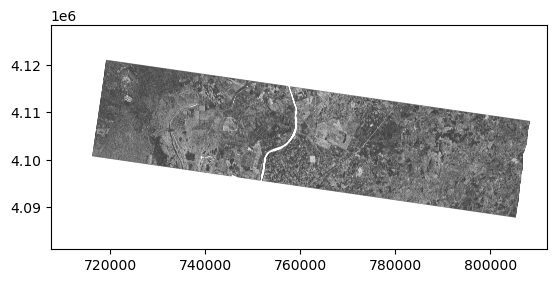

In [15]:
with rasterio.open('openEO_2018-01-28Z.tif') as src:
    show(src.read(1), transform=src.transform, cmap='gray')

### 2) Visualization in the openEO Web Editor

Open the [OpenEO Web Editor](https://openeo.dataspace.copernicus.eu/), search the job that has been executed and click on *View the results*

![image](https://raw.githubusercontent.com/cloudinsar/s1-workflows/refs/heads/main/notebooks/LPS_DEMO/images/openEO_webeditor.png)

### 3) Visualization in GIS software (QGIS)

Visualize the job result with job.get_results() and click on "Copy URL"

In [5]:
job.get_results()

<JobResults for job 'j-260414133329491b83f6e8beed3eaf6b'>

Alternatively the URL can be directly visualized with `job.get_results().get_assets()`

In [6]:
job.get_results().get_assets()

[<ResultAsset 'openEO_2018-01-28Z.tif' (type image/tiff; application=geotiff) at 'https://s3.waw3-1.openeo.v1.dataspace.copernicus.eu/openeo-data-prod-waw4-1/batch_jobs/j-260414133329491b83f6e8beed3eaf6b/openEO_2018-01-28Z.tif?X-Proxy-Head-As-Get=true&X-Amz-Algorithm=AWS4-HMAC-SHA256&X-Amz-Credential=09c3d9d28d7944a2824286430ce73914%2F20260414%2Fwaw4-1%2Fs3%2Faws4_request&X-Amz-Date=20260414T135847Z&X-Amz-Expires=86400&X-Amz-SignedHeaders=host&X-Amz-Security-Token=eyJhbGciOiJSUzI1NiIsInR5cCI6IkpXVCJ9.eyJyb2xlX2FybiI6ImFybjpvcGVuZW93czppYW06Ojpyb2xlL29wZW5lby1kYXRhLXByb2Qtd2F3NC0xLXdvcmtzcGFjZSIsImluaXRpYWxfaXNzdWVyIjoib3BlbmVvLnByb2Qud2F3My0xLm9wZW5lby1pbnQudjEuZGF0YXNwYWNlLmNvcGVybmljdXMuZXUiLCJodHRwczovL2F3cy5hbWF6b24uY29tL3RhZ3MiOnsicHJpbmNpcGFsX3RhZ3MiOnsiam9iX2lkIjpbImotMjYwNDE0MTMzMzI5NDkxYjgzZjZlOGJlZWQzZWFmNmIiXSwidXNlcl9pZCI6WyI1YWQ5OGFmMC1kNDZlLTQwOTQtODRjYS1kYmMzYWUyOWU2YTkiXX0sInRyYW5zaXRpdmVfdGFnX2tleXMiOlsidXNlcl9pZCIsImpvYl9pZCJdfSwiaXNzIjoic3RzLndhdzMtMS5vcGVuZW8udjEuZG

Then open QGIS. Click on *Open Data Source Manager* and select the protocol *HTTPS* as *Source Type*. Then paste the URL and add the layer

![image](https://raw.githubusercontent.com/cloudinsar/s1-workflows/refs/heads/main/notebooks/LPS_DEMO/images/qgis_visualization.png)